<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

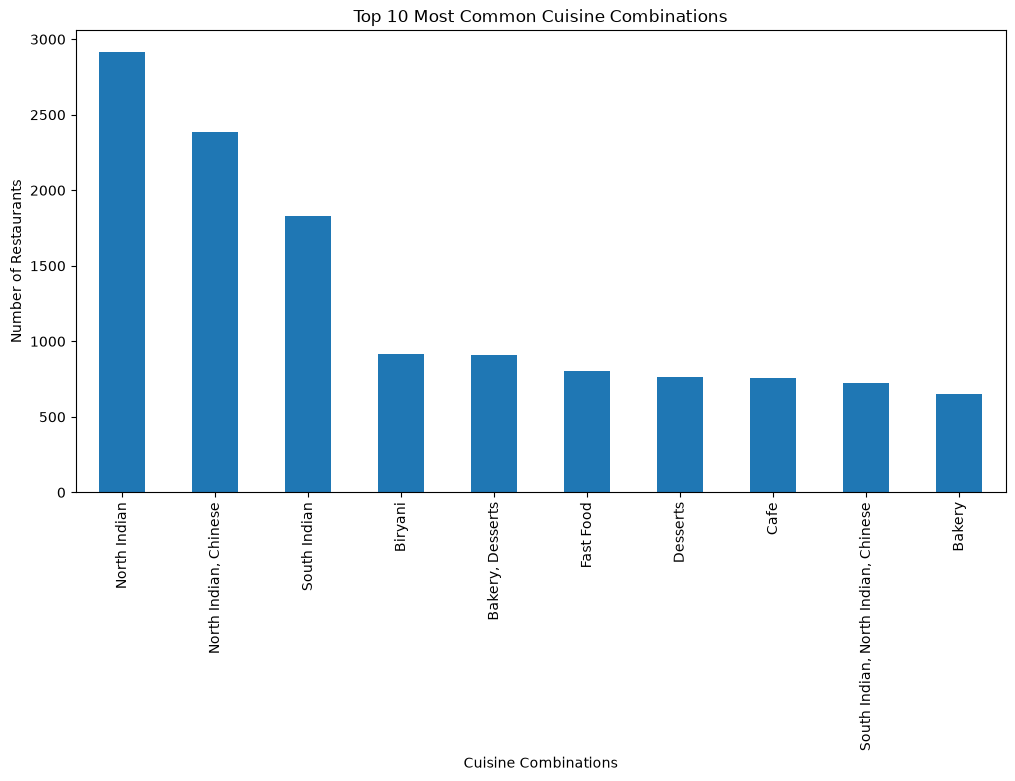

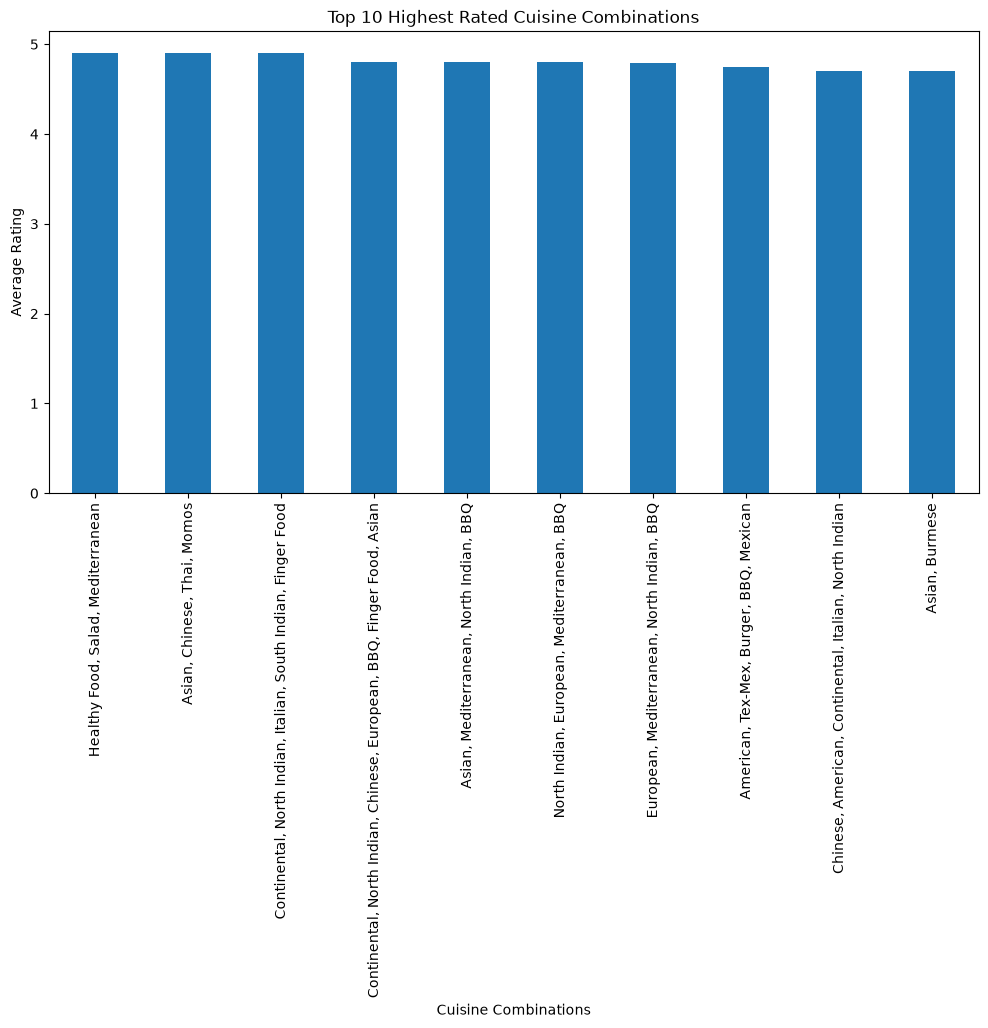

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("zomato.csv")

df.head()

df.info()

df.isnull().sum()

common_cuisines = df["cuisines"].value_counts()

common_cuisines.head(10)

common_cuisines.head(10).plot(kind="bar", figsize=(12,6))
plt.title("Top 10 Most Common Cuisine Combinations")
plt.xlabel("Cuisine Combinations")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=90)
plt.show()

df["rate"] = df["rate"].str.replace("/5", "", regex=False)
df["rate"] = pd.to_numeric(df["rate"], errors="coerce")

avg_rating = (
    df.groupby("cuisines")["rate"]
      .mean()
      .dropna()
      .sort_values(ascending=False)
)

avg_rating.head(10)

avg_rating.head(10).plot(kind="bar", figsize=(12,6))
plt.title("Top 10 Highest Rated Cuisine Combinations")
plt.xlabel("Cuisine Combinations")
plt.ylabel("Average Rating")
plt.xticks(rotation=90)
plt.show()